# Random Forest: normalised features

Same Random Forest as `reeval_random_forest.ipynb` (`max_depth=15, n_estimators=150`), with the preprocessing steps below. S3 is skipped: per-feature scaling does not change a tree's splits.

**Preprocessing steps** (cumulative, see `src/reeval_normalized.py`):

| Step | What changes |
|---|---|
| S0 | Thesis features, unchanged. Result taken from `results/reeval/`. |
| S1 | Undetected keypoints (x = y = 0) filled by linear interpolation over time, so they no longer create fake jumps. |
| S2 | S1, then coordinates divided by the recording's median torso length (neck to mid-hip), so displacements no longer depend on body size or distance from the camera. |
| S3 | S2, then each keypoint's dx and dy standardised with the training fold's mean and SD (neural networks only). |

Everything else is identical to the `reeval_*` notebooks: the 41 recordings, 6 classes, the same 15 recording-level splits, the same model settings. Only the input changes, so each step's effect can be read off directly.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "keypoint_sequences.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import reeval_common as rc
import reeval_normalized as rn

rn.use_results_dir()
records = rc.load_recordings()

## What the preprocessing does to the data

In [2]:
X_raw, _, _ = rn.displacement_windows(records, interpolate=False, scale=False)
X_s1, _, _ = rn.displacement_windows(records, interpolate=True, scale=False)
torso = pd.Series([rn.torso_length(r["frames"]) for r in records])
pd.DataFrame({
    "windows with a jump > 100 px": [f"{rn.spike_share(X_raw):.0%}", f"{rn.spike_share(X_s1):.0%}"],
    "median |displacement| (px)": [f"{np.median(np.abs(X_raw)):.2f}", f"{np.median(np.abs(X_s1)):.2f}"],
}, index=["S0 raw", "S1 interpolated"]).assign(**{"torso length px (min / median / max)": f"{torso.min():.0f} / {torso.median():.0f} / {torso.max():.0f}"})

,windows with a jump > 100 px,median |displacement| (px),torso length px (min / median / max)
S0 raw,45%,2.55,93 / 107 / 117
S1 interpolated,6%,2.55,93 / 107 / 117


## Model (same settings as the thesis re-evaluation)

In [3]:
from sklearn.ensemble import RandomForestClassifier


def make_fit_predict(standardise):
    # Trees are unaffected by per-feature scaling, so S3 is not run for Random Forest.
    def fit_predict(X_train, y_train, groups_train, X_test, seed):
        clf = RandomForestClassifier(max_depth=15, n_estimators=150, random_state=seed, n_jobs=-1)
        clf.fit(X_train.reshape(len(X_train), -1), y_train)
        return clf.predict(X_test.reshape(len(X_test), -1))
    return fit_predict

## Results per step

In [4]:
results = {"S0": rn.load_raw_result("random_forest")}
STEP_FLAGS = {"S1": (True, False, False), "S2": (True, True, False), "S3": (True, True, True)}

for step in ['S1', 'S2']:
    interpolate, scale, standardise = STEP_FLAGS[step]
    X, y, groups = rn.displacement_windows(records, interpolate=interpolate, scale=scale)
    results[step] = rc.evaluate(
        make_fit_predict(standardise), X, y, groups, rc.recording_splits(groups, records),
        model="Random Forest", variant=f"{step}: {rn.STEPS[step]}", split="recording-level 5-fold × 3",
        features="displacement windows, flattened (1,250)", params="max_depth=15, n_estimators=150",
    )
    rc.save_results(results[step], f"random_forest_{step}")

rc.summary_table(list(results.values()))

,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,Random Forest,S0: thesis features (raw),recording-level 5-fold × 3,121,15,61.2% ± 7.9%,55.8% ± 9.2%,66.9% ± 14.5%,27.1%
1,Random Forest,S1: missing-joint interpolation,recording-level 5-fold × 3,121,15,62.9% ± 7.4%,57.8% ± 9.7%,69.4% ± 12.7%,27.1%
2,Random Forest,S2: S1 + torso-length scaling,recording-level 5-fold × 3,121,15,61.7% ± 8.4%,56.4% ± 10.8%,62.5% ± 12.0%,27.1%


Change against S0 on the same splits (a split counts as better if accuracy is higher):

In [5]:
last = list(results)[-1]
s0 = np.array([f["accuracy"] for f in results["S0"]["folds"]])
rows = []
for step in list(results)[1:]:
    acc = np.array([f["accuracy"] for f in results[step]["folds"]])
    diff = acc - s0
    rows.append({"step": step, "mean change vs S0": f"{diff.mean():+.1%}", "better / equal / worse splits": f"{(diff > 0).sum()} / {(diff == 0).sum()} / {(diff < 0).sum()}"})
pd.DataFrame(rows)

,step,mean change vs S0,better / equal / worse splits
0,S1,+1.7%,7 / 5 / 3
1,S2,+0.5%,6 / 5 / 4


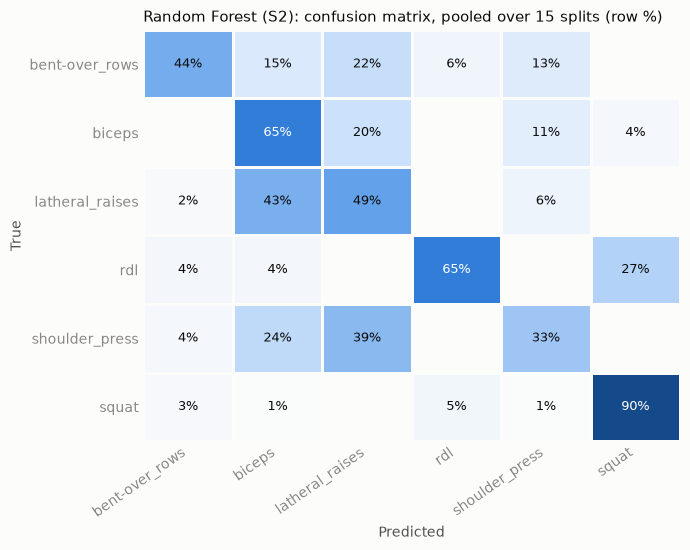

In [6]:
rc.plot_confusion(results[last], f"Random Forest ({last}): confusion matrix, pooled over 15 splits (row %)", f"random_forest_{last}_confusion.png");